# Тема. Алгоритми пошуку
## **Мета:** засвоїти варіанти реалізації алгоритмів пошуку засобами Python і методи оцінювання їх складності.  
### Зробив: Цубера Артем

**Завдання 1:** оцінити асимптотичну складність алгоритму лінійного пошуку в О-нотації.

#### Реалізація лінійного пошуку.

In [30]:
import time  # Додай цей рядок!
import pandas as pd
import random
# Функція лінійного пошуку
def linear_search(a_list, x):
    # i - початковий індекс, length - кількість елементів у списку
    i, length = 0, len(a_list)
    
    # Цикл працює, поки ми не дійшли до кінця і не знайшли елемент
    while i < length and x != a_list[i]:
        i += 1
        
    # Якщо i < length, значить елемент знайдено, повертаємо його індекс
    # Інакше повертаємо -1 (елемент не знайдено)
    return i if i < length else -1

 # Функція для створення звіту в DataFrame

**асимптотичну складність алгоритму:** O(n),бо час виконання цього алгоритму залежить від довжини вхідного масиву, і найгіршим випадком вважається те, що шуканий елемент в кінці або його взагалі нема. При цих випадках алгоритму прийдеться проходити по всьому масиві

**Задання 2:**<br>
  − оцінити асимптотичну складність алгоритму бінарного пошуку в О-нотації.<br>
  − написати функцію, яка б могла повертати датафрейм з таким складом полів: («n», «time»), де n – розмір масиву для функції linear_searh();<br>
  − написати функцію, яка б могла повертати датафрейм з таким складом полів: («n», «time»), де n – розмір масиву для функції bin_searh();<br>
  − за результатами попередніх завдань побудувати графіки залежності часу виконання процедури пошуку від розміру масиву.<br>
  − оцінити, який з двох алгоритмів є ефективнішим і в якому діапазоні розміру задачі.

#### Реалізація бінарного пошуку.

In [31]:
import time
import pandas as pd
import random
def bin_search(a_list, x, left, right):
    if left > right or len(a_list) == 0:
        return -1
    
    middle = (left + right) // 2
    
    if a_list[middle] == x:
        return middle
    elif (a_list[middle] < x):
        return bin_search(a_list, x, middle + 1, right)
    else:            # a_list[middle] > x
        return bin_search(a_list, x, left, middle - 1)


**асимптотичну складність алгоритму:**<br>
**Найкращий випадок** — $O(1)$: Це ситуація, коли серединний елемент масиву одразу збігається із шуканим. У такому разі алгоритм виконує лише одну операцію порівняння і миттєво завершує роботу.<br>
**Найгірший випадок** — $O(\log n)$: Кожна ітерація алгоритму порівнює середній елемент із шуканим. Якщо вони не рівні, масив ділиться на дві частини: ліву та праву. Залежно від того, більший чи менший шуканий елемент за середній, алгоритм відкидає непотрібну половину і продовжує пошук у решті масиву.

Функція, яка б могла повертати датафрейм з таким складом полів: («n», «time»), де n – розмір масиву для функціЙ

        n    linear    binary
0     100  0.000008  0.000004
1    1000  0.000072  0.000006
2   10000  0.000819  0.000014
3  100000  0.011035  0.000018
4  500000  0.069777  0.000018


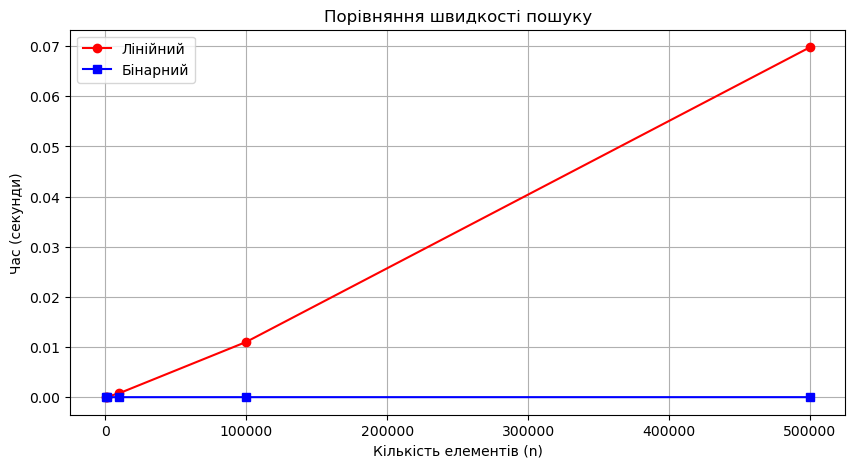

In [37]:
import time
import random
import pandas as pd
import matplotlib.pyplot as plt

# 1. Заміряємо час
results = []
test_sizes = [100, 1000, 10000, 100000, 500000]

for n in test_sizes:
    # Готуємо дані (один масив для обох)
    arr = sorted([random.randint(1, 1000000) for _ in range(n)])
    target = -1 # Шукаємо те, чого немає (найгірший випадок)

    # Лінійний пошук
    t1 = time.perf_counter()
    linear_search(arr, target)
    t_lin = time.perf_counter() - t1

    # Бінарний пошук
    t2 = time.perf_counter()
    bin_search(arr, target, 0, len(arr) - 1)
    t_bin = time.perf_counter() - t2

    # Зберігаємо результат
    results.append({'n': n, 'linear': t_lin, 'binary': t_bin})

# 2. Створюємо таблицю
df = pd.DataFrame(results)
print(df) # Виведе таблицю в консоль

# 3. Малюємо графік
plt.figure(figsize=(10, 5))
plt.plot(df['n'], df['linear'], 'o-', color='red', label='Лінійний')
plt.plot(df['n'], df['binary'], 's-', color='blue', label='Бінарний')

plt.title('Порівняння швидкості пошуку')
plt.xlabel('Кількість елементів (n)')
plt.ylabel('Час (секунди)')
plt.legend()
plt.grid(True)
plt.show()

Бінарний пошук буде ефективніший за лінійний, але за умови того, що масив буде відсортовано. При маленьких масивах краще використовувати лінійний, а при великих — бінарний. Також реалізація бінарного пошуку трішки складніша, а для невідсортованих масивів потрібно буде їх спочатку відсортувати. Тому, коли тобі потрібно одноразово знайти елемент, краще використати лінійний пошук, а коли потрібно знаходити елементи часто — краще обрати бінарний.

**Контрольні питання:** 
1. Задача пошуку: Це процес знаходження індексу (позиції) елемента з заданим значенням у структурі даних або встановлення факту його відсутності.
2. Критерії ефективності: Основними критеріями є часова складність (кількість операцій для знаходження елемента) та просторова складність (кількість додаткової пам'яті).
3. Лінійний пошук: Це алгоритм, який послідовно перевіряє кожен елемент масиву по черзі, а його асимптотична складність становить $O(n)$.
4. Бінарний пошук: Це алгоритм для відсортованих даних, принцип якого полягає в постійному поділі масиву навпіл для звуження зони пошуку вдвічі на кожному кроці.
5. Переваги та недоліки: Головна перевага — дуже висока швидкість на великих даних ($O(\log n)$), а недоліки — обов'язкова відсортованість масиву та складніша логіка порівняно з лінійним.
6. Інші алгоритми: Існують також інтерполяційний пошук, стрибковий пошук (Jump Search), експоненціальний пошук та пошук через хеш-таблиці.

**Висноввок:** Засвоїв варіанти реалізації алгоритмів пошуку засобами Python і методи оцінювання їх складності.